In [1]:
!pip install pycox torchtuples

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.9/412.9 kB 20.0 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=7546549b20cc6436735682a990f8dd5c2a72b18255c67d2dbf81d13a789df571
  Stored in directory: /root/.cache/pip/wheels/77/5b/0e/0e63d10b6353208a085a321ea2eed2578f220a77bb8a4bd7ab
Successfully built feather-format


Test Concordance Index (C-index): 0.626
Best alpha with non-zero coefficients: 0.0001


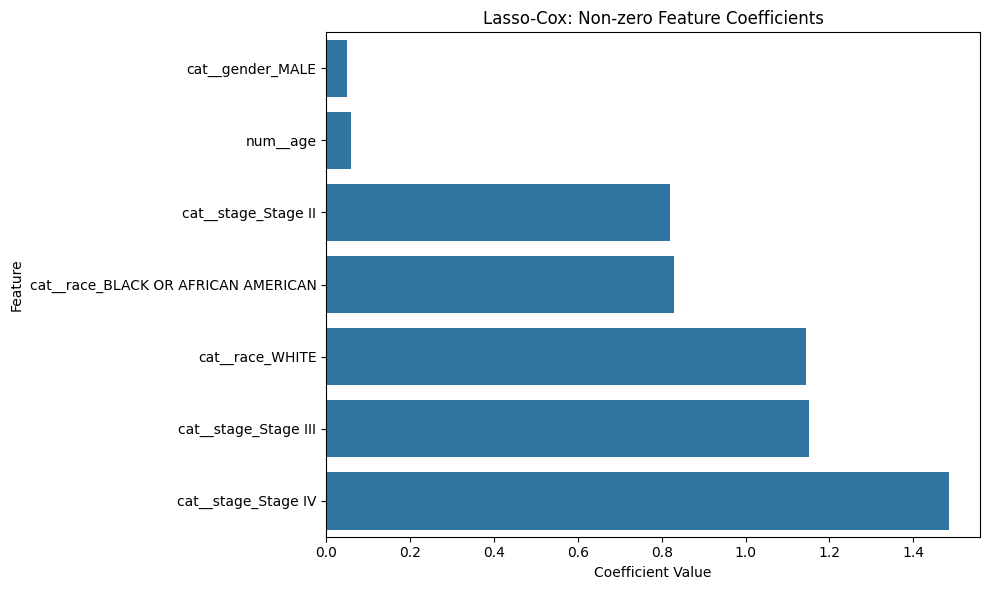

In [10]:
!pip install scikit-survival

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

# Load dataset
df = pd.read_csv("TCGA_LUAD_final_for_OS_model.csv")
df = df.drop(columns=["patient_id", "PFI", "PFI.time"])

# Format survival outcome
y = Surv.from_arrays(event=df["OS"].astype(bool), time=df["OS.time"])
X = df.drop(columns=["OS", "OS.time"])

# Define columns
categorical_cols = ["gender", "race", "stage"]
numerical_cols = ["age"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42)

# Fit Lasso-Cox model (penalized Cox regression)
coxnet = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=np.logspace(-4, 4, 100))
coxnet.fit(X_train, y_train)

# Evaluate test set performance
c_index = concordance_index_censored(
    y_test["event"], y_test["time"], coxnet.predict(X_test))[0]
print("Test Concordance Index (C-index):", round(c_index, 3))

# Find best alpha with non-zero coefficients
nonzero_mask = np.any(coxnet.coef_ != 0, axis=1)
if np.any(nonzero_mask):
    best_index = np.where(nonzero_mask)[0][0]
    best_alpha = coxnet.alphas_[best_index]
    print("Best alpha with non-zero coefficients:", best_alpha)

    # Refit best model
    best_model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[best_alpha])

    best_model.fit(X_train, y_train)

    # Extract non-zero coefficients
    coefs = pd.Series(best_model.coef_.flatten(), index=feature_names)
    nonzero_coefs = coefs[coefs != 0].sort_values()

    # Plot important features
    plt.figure(figsize=(10, 6))
    sns.barplot(x=nonzero_coefs.values, y=nonzero_coefs.index)
    plt.title("Lasso-Cox: Non-zero Feature Coefficients")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No alpha produced non-zero coefficients.")


In [11]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 9.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=93d6e2cdadb6709d376a7e3f27b9e69ef8e7edb29a95ed4c07fad33a5056e72a
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


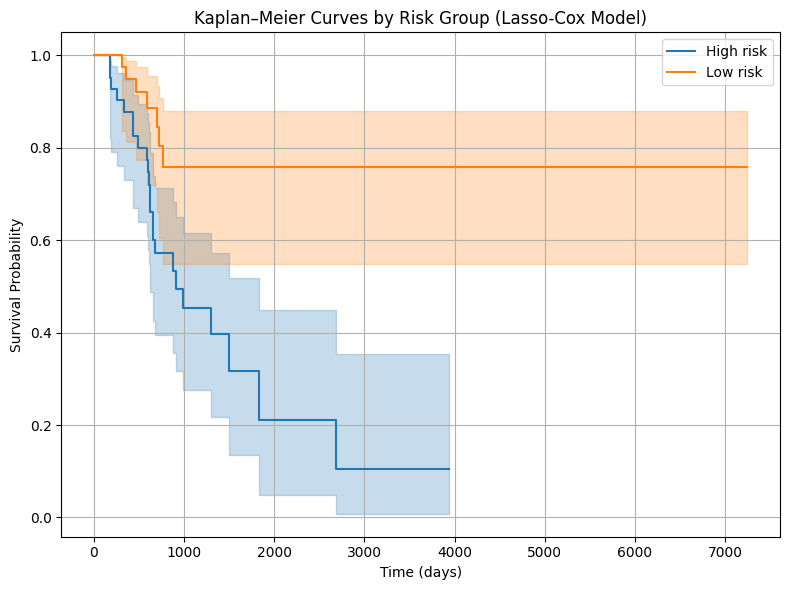

,test_statistic,p,-log2(p)
0,8.848087,0.002934,8.412934


In [12]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Predict linear risk scores from best model
risk_scores = best_model.predict(X_test)

# Create a median-based binary risk group
risk_group = pd.Series(risk_scores, name="risk_score")
median_cutoff = risk_group.median()
risk_group_label = (risk_group > median_cutoff).map({False: "Low risk", True: "High risk"})

# Prepare survival data
survival_df = pd.DataFrame({
    "time": y_test["time"],
    "event": y_test["event"],
    "group": risk_group_label.values
})

# Fit KM curves
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8, 6))

for label, kmf in zip(["High risk", "Low risk"], [kmf_high, kmf_low]):
    mask = survival_df["group"] == label
    kmf.fit(durations=survival_df["time"][mask], event_observed=survival_df["event"][mask], label=label)
    kmf.plot_survival_function(ax=ax)

plt.title("Kaplan–Meier Curves by Risk Group (Lasso-Cox Model)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

# Log-rank test
logrank_result = logrank_test(
    survival_df["time"][risk_group_label == "Low risk"],
    survival_df["time"][risk_group_label == "High risk"],
    event_observed_A=survival_df["event"][risk_group_label == "Low risk"],
    event_observed_B=survival_df["event"][risk_group_label == "High risk"]
)

logrank_result.summary


In [ ]:
"""
Part 4: Lasso-Penalized Cox Model (Regularized Predictive Model)
-----------------------------------------------------------------
- Approach: L1-regularized Cox model using scikit-survival (CoxnetSurvivalAnalysis).
- Strengths:
  - Automatically selected key predictive features via Lasso (L1 penalty).
  - Built a survival risk score for each patient.
  - Stratified patients into high-risk vs. low-risk groups using predicted risk.
  - Kaplan–Meier curves for risk groups showed clear separation.
  - Log-rank test p-value = 0.0029 → statistically significant difference in survival.
  - Test Concordance Index (C-index): 0.626

Top Selected Predictive Features:
- Stage IV, III, II (increasing hazard)
- Race (WHITE, BLACK OR AFRICAN AMERICAN)
- Gender (MALE)
- Age (positive association with hazard)

Summary Table:
---------------
| Aspect                     | Part 3 (KM + Cox)          | Part 4 (Lasso-Cox)                    |
|---------------------------|-----------------------------|----------------------------------------|
| Model Type                | KM + Cox PH                 | Penalized Cox (L1)                    |
| Feature Selection         | Manual                      | Automatic (Lasso)                    |
| Risk Stratification       | No                          | Yes (KM by risk group)               |
| C-index                   | ~0.61–0.63                  | 0.626                                |
| Interpretation            | Biomarker-level             | Patient-level risk scoring           |
| Statistical Testing       | Per biomarker (log-rank)    | Group-level (KM + log-rank p=0.0029) |

Conclusion:
-----------
- Part 3 provided detailed biological insights into prognostic markers.
- Part 4 improved prediction accuracy, reduced overfitting, and enabled clinically actionable risk stratification.
"""
